# Linear Resampling vs DTW Alignment (Simple Visual Demo)

This notebook shows, with a synthetic example, why linear resampling alone is not enough and how DTW improves phase alignment.

Pipeline shown:
1. Create two curves with the same overall pattern but local speed differences.
2. Linearly resample both to fixed length $L$.
3. Align one curve to the other with DTW.
4. Visualize the warping path and the DTW-aligned result.

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Uses the same package style as your pipeline.py
from dtw import dtw

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')

In [13]:
# --- Helper functions ---
def base_shape(t):
    # Three phases: warm-up bump, plateau oscillation, cool-down dip
    return (
        1.1 * np.exp(-0.5 * ((t - 0.22) / 0.07) ** 2)
        + 0.35 * np.sin(6 * np.pi * t)
        + 0.55 * np.exp(-0.5 * ((t - 0.67) / 0.09) ** 2)
        - 0.65 * np.exp(-0.5 * ((t - 0.88) / 0.05) ** 2)
    )

def make_reference_curve(n=170, noise=0.03):
    t = np.linspace(0, 1, n)
    y = base_shape(t) + noise * np.random.randn(n)
    return t, y

def make_time_distorted_curve(n=135, noise=0.03):
    # Build non-uniform internal clock: faster in one region, slower in another
    t_obs = np.linspace(0, 1, n)
    internal_t = t_obs.copy()

    # Speed-up around early-middle region
    internal_t += 0.10 * np.exp(-0.5 * ((t_obs - 0.35) / 0.10) ** 2)
    # Slow-down around late-middle region
    internal_t -= 0.12 * np.exp(-0.5 * ((t_obs - 0.70) / 0.12) ** 2)

    internal_t = np.clip(internal_t, 0, 1)
    internal_t = np.maximum.accumulate(internal_t)  # enforce monotonicity

    y = base_shape(internal_t) + noise * np.random.randn(n)
    return t_obs, y, internal_t

def linear_resample(y, L):
    x_old = np.linspace(0, 1, len(y))
    x_new = np.linspace(0, 1, L)
    return np.interp(x_new, x_old, y)

def align_curve_with_dtw(query, reference):
    # Same logic as your pipeline helper: map query samples to reference positions
    alignment = dtw(query, reference, keep_internals=True)
    aligned = np.zeros(len(reference))
    counts = np.zeros(len(reference))

    for qi, ri in zip(alignment.index1, alignment.index2):
        aligned[ri] += query[qi]
        counts[ri] += 1

    counts = np.where(counts == 0, 1, counts)
    aligned = aligned / counts
    return aligned, alignment

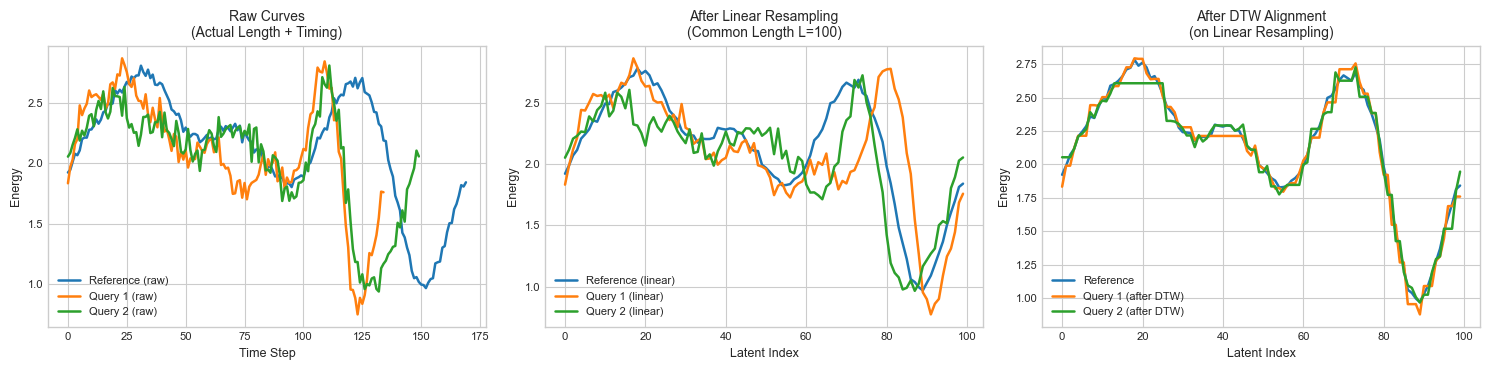

Query 1 MSE (linear only): 0.1315
Query 1 MSE (after DTW) : 0.0028
Query 2 MSE (linear only): 0.0730
Query 2 MSE (after DTW) : 0.0038


In [14]:
# --- One compact visual with 3 curves: 1 reference + 2 queries ---
t_ref, y_ref = make_reference_curve(n=170)

# Query 1: distortion profile A
t_q1, y_q1, _ = make_time_distorted_curve(n=135)

# Query 2: distortion profile B (different local speed changes)
t_q2 = np.linspace(0, 1, 150)
internal_t2 = t_q2.copy()
internal_t2 += 0.14 * np.exp(-0.5 * ((t_q2 - 0.25) / 0.09) ** 2)
internal_t2 -= 0.10 * np.exp(-0.5 * ((t_q2 - 0.62) / 0.10) ** 2)
internal_t2 += 0.06 * np.exp(-0.5 * ((t_q2 - 0.82) / 0.07) ** 2)
internal_t2 = np.clip(internal_t2, 0, 1)
internal_t2 = np.maximum.accumulate(internal_t2)
y_q2 = base_shape(internal_t2) + 0.03 * np.random.randn(len(t_q2))

# Make query curves more different beyond timing (amplitude + local signal + extra noise)
y_q1 = 1.10 * y_q1 + 0.15 * np.sin(10 * np.pi * t_q1) + 0.06 * np.random.randn(len(t_q1))
y_q2 = 0.88 * y_q2 + 0.12 * np.cos(8 * np.pi * t_q2) + 0.08 * np.random.randn(len(t_q2))

# Shift to positive-energy domain and enforce strictly positive values
OFFSET = 1.9
y_ref = np.clip(y_ref + OFFSET, 0.05, None)
y_q1 = np.clip(y_q1 + OFFSET, 0.05, None)
y_q2 = np.clip(y_q2 + OFFSET, 0.05, None)

# Panel A should show actual real length (time steps), not normalized time
x_ref_real = np.arange(len(y_ref))
x_q1_real = np.arange(len(y_q1))
x_q2_real = np.arange(len(y_q2))

# Step 1: linear resampling to common length
L = 100
x_latent = np.arange(L)
y_ref_lin = linear_resample(y_ref, L)
y_q1_lin = linear_resample(y_q1, L)
y_q2_lin = linear_resample(y_q2, L)

# Step 2: DTW alignment on top of linear resampling
y_q1_dtw, _ = align_curve_with_dtw(y_q1_lin, y_ref_lin)
y_q2_dtw, _ = align_curve_with_dtw(y_q2_lin, y_ref_lin)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))

# Panel A: raw different-length curves (3 curves)
axes[0].plot(x_ref_real, y_ref, label='Reference (raw)', linewidth=1.8)
axes[0].plot(x_q1_real, y_q1, label='Query 1 (raw)', linewidth=1.8)
axes[0].plot(x_q2_real, y_q2, label='Query 2 (raw)', linewidth=1.8)
axes[0].set_title('Raw Curves\n(Actual Length + Timing)', fontsize=10)
axes[0].set_xlabel('Time Step', fontsize=9)
axes[0].set_ylabel('Energy', fontsize=9)
axes[0].tick_params(labelsize=8)
axes[0].legend(fontsize=8, loc='best')

# Panel B: after linear resampling (3 curves)
axes[1].plot(x_latent, y_ref_lin, label='Reference (linear)', linewidth=1.8)
axes[1].plot(x_latent, y_q1_lin, label='Query 1 (linear)', linewidth=1.8)
axes[1].plot(x_latent, y_q2_lin, label='Query 2 (linear)', linewidth=1.8)
axes[1].set_title('After Linear Resampling\n(Common Length L=100)', fontsize=10)
axes[1].set_xlabel('Latent Index', fontsize=9)
axes[1].set_ylabel('Energy', fontsize=9)
axes[1].tick_params(labelsize=8)
axes[1].legend(fontsize=8, loc='best')

# Panel C: after DTW alignment (3 curves)
axes[2].plot(x_latent, y_ref_lin, label='Reference', linewidth=1.8)
axes[2].plot(x_latent, y_q1_dtw, label='Query 1 (after DTW)', linewidth=1.8)
axes[2].plot(x_latent, y_q2_dtw, label='Query 2 (after DTW)', linewidth=1.8)
axes[2].set_title('After DTW Alignment\n(on Linear Resampling)', fontsize=10)
axes[2].set_xlabel('Latent Index', fontsize=9)
axes[2].set_ylabel('Energy', fontsize=9)
axes[2].tick_params(labelsize=8)
axes[2].legend(fontsize=8, loc='best')

plt.tight_layout()
plt.show()

mse_q1_linear = np.mean((y_q1_lin - y_ref_lin) ** 2)
mse_q1_dtw = np.mean((y_q1_dtw - y_ref_lin) ** 2)
mse_q2_linear = np.mean((y_q2_lin - y_ref_lin) ** 2)
mse_q2_dtw = np.mean((y_q2_dtw - y_ref_lin) ** 2)

print(f'Query 1 MSE (linear only): {mse_q1_linear:.4f}')
print(f'Query 1 MSE (after DTW) : {mse_q1_dtw:.4f}')
print(f'Query 2 MSE (linear only): {mse_q2_linear:.4f}')
print(f'Query 2 MSE (after DTW) : {mse_q2_dtw:.4f}')


Panel notes for LaTeX:
(a) Original curves with different lengths and different internal event timing.
(b) Curves after linear resampling to a common 100-point representation; timing differences remain.
(c) Curves after DTW alignment to the DBA barycenter; timing is corrected while value differences remain.


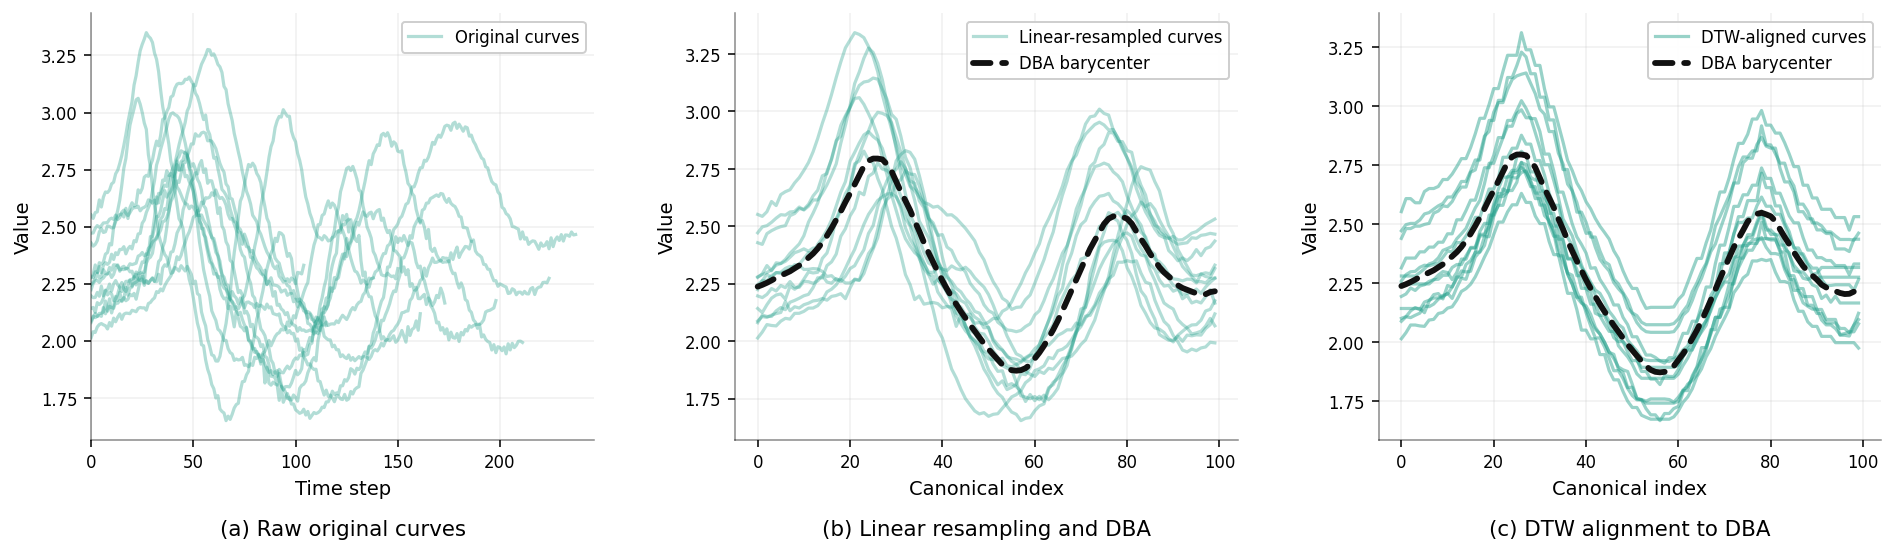


Saved visual to: visuals/dba_dtw_alignment.pdf
 Curve 1 | raw length=105 | peak1=0.222 | valley=0.596 | peak2=0.757 | raw MSE before=0.03092 | raw MSE after=0.01513 | shape MSE before=0.23083 | shape MSE after=0.00451
 Curve 2 | raw length=116 | peak1=0.328 | valley=0.575 | peak2=0.803 | raw MSE before=0.04037 | raw MSE after=0.02164 | shape MSE before=0.28313 | shape MSE after=0.00378
 Curve 3 | raw length=127 | peak1=0.224 | valley=0.564 | peak2=0.754 | raw MSE before=0.14391 | raw MSE after=0.12507 | shape MSE before=0.24011 | shape MSE after=0.00439
 Curve 4 | raw length=139 | peak1=0.327 | valley=0.542 | peak2=0.841 | raw MSE before=0.03112 | raw MSE after=0.00262 | shape MSE before=0.49553 | shape MSE after=0.02521
 Curve 5 | raw length=151 | peak1=0.273 | valley=0.587 | peak2=0.839 | raw MSE before=0.02565 | raw MSE after=0.00648 | shape MSE before=0.25483 | shape MSE after=0.01042
 Curve 6 | raw length=162 | peak1=0.274 | valley=0.593 | peak2=0.778 | raw MSE before=0.02115 | r

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tslearn.barycenters import dtw_barycenter_averaging
from dtw import dtw

# ============================================================
# Reproducibility
# ============================================================
np.random.seed(12)

# ============================================================
# Output folder
# ============================================================
os.makedirs("visuals", exist_ok=True)

# ============================================================
# Plot style
# ============================================================
plt.style.use("default")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 8.5,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 140,
})


# ============================================================
# Helper functions
# ============================================================
def moving_average(y, window=7):
    """
    Smooth curve while preserving length.
    """
    y = np.asarray(y, dtype=float)

    if window <= 1:
        return y.copy()

    pad = window // 2
    y_pad = np.pad(y, pad_width=pad, mode="edge")
    kernel = np.ones(window) / window

    return np.convolve(y_pad, kernel, mode="valid")


def z_normalize(y, eps=1e-8):
    """
    Shape normalization for DBA/DTW path computation.
    """
    y = np.asarray(y, dtype=float)
    return (y - np.mean(y)) / (np.std(y) + eps)


def linear_resample(y, fixed_length):
    """
    Linearly resample one curve to fixed_length points.
    """
    x_old = np.linspace(0, 1, len(y))
    x_new = np.linspace(0, 1, fixed_length)
    return np.interp(x_new, x_old, y)


def event_shape(
    t,
    peak1_center=0.27,
    peak1_width=0.055,
    valley_center=0.56,
    valley_width=0.075,
    peak2_center=0.79,
    peak2_width=0.060,
):
    """
    A clean activity/value shape with two peaks and one valley.
    """
    baseline = 2.2

    slow_trend = 0.10 * np.sin(2 * np.pi * t - 0.4)

    peak1 = 0.65 * np.exp(-0.5 * ((t - peak1_center) / peak1_width) ** 2)
    valley = -0.45 * np.exp(-0.5 * ((t - valley_center) / valley_width) ** 2)
    peak2 = 0.58 * np.exp(-0.5 * ((t - peak2_center) / peak2_width) ** 2)

    small_wave = 0.08 * np.sin(4 * np.pi * t + 0.6)

    return baseline + slow_trend + peak1 + valley + peak2 + small_wave


def make_training_curve(n):
    """
    Create one raw curve.

    Curves differ in total length, internal timing, amplitude, offset,
    and residual value deviations.
    """
    t = np.linspace(0, 1, n)

    # Different event timing per curve.
    peak1_center = 0.27 + np.random.uniform(-0.070, 0.070)
    valley_center = 0.56 + np.random.uniform(-0.075, 0.075)
    peak2_center = 0.79 + np.random.uniform(-0.070, 0.070)

    peak1_width = 0.055 * np.random.uniform(0.80, 1.30)
    valley_width = 0.075 * np.random.uniform(0.80, 1.30)
    peak2_width = 0.060 * np.random.uniform(0.80, 1.30)

    y = event_shape(
        t,
        peak1_center=peak1_center,
        peak1_width=peak1_width,
        valley_center=valley_center,
        valley_width=valley_width,
        peak2_center=peak2_center,
        peak2_width=peak2_width,
    )

    # Value differences that DTW should not remove.
    amp = np.random.uniform(0.90, 1.12)
    offset = np.random.uniform(-0.16, 0.18)

    y = amp * y + offset

    # Smooth local residuals, so curves remain above/below barycenter.
    residual = np.zeros_like(t)

    for _ in range(np.random.randint(2, 4)):
        center = np.random.uniform(0.15, 0.90)
        width = np.random.uniform(0.05, 0.13)
        height = np.random.uniform(-0.08, 0.08)

        residual += height * np.exp(-0.5 * ((t - center) / width) ** 2)

    y += residual

    # Small noise.
    y += np.random.uniform(0.010, 0.022) * np.random.randn(n)

    y = np.clip(y, 0.05, None)

    return {
        "t": t,
        "raw_values": y,
        "length": n,
        "peak1_center": peak1_center,
        "valley_center": valley_center,
        "peak2_center": peak2_center,
    }


def get_dtw_indices(alignment):
    """
    Compatibility helper for dtw-python.
    """
    if hasattr(alignment, "index1"):
        idx_curve = np.asarray(alignment.index1)
        idx_bary = np.asarray(alignment.index2)
    else:
        idx_curve = np.asarray(alignment.index1s)
        idx_bary = np.asarray(alignment.index2s)

    return idx_curve, idx_bary


def warp_curve_to_barycenter_with_dtw(
    curve_values,
    barycenter_shape,
    window_size=11,
    smooth_window=7,
):
    """
    DTW-align one curve to the DBA barycenter.

    Important:
    - DTW path is computed on smoothed + normalized shapes.
    - The path is applied to the original curve values.
    - Timing is corrected, but value differences remain.
    """
    curve_values = np.asarray(curve_values, dtype=float)
    barycenter_shape = np.asarray(barycenter_shape, dtype=float)

    fixed_length = len(barycenter_shape)

    # Path computation only.
    curve_for_path = z_normalize(moving_average(curve_values, window=smooth_window))
    bary_for_path = z_normalize(moving_average(barycenter_shape, window=smooth_window))

    x = curve_for_path.reshape(-1, 1)
    y = bary_for_path.reshape(-1, 1)

    alignment = dtw(
        x,
        y,
        keep_internals=True,
        window_type="sakoechiba",
        window_args={"window_size": window_size},
    )

    idx_curve, idx_bary = get_dtw_indices(alignment)

    warped_values = np.full(fixed_length, np.nan)

    for j in range(fixed_length):
        vals = curve_values[idx_curve[idx_bary == j]]

        if len(vals) > 0:
            warped_values[j] = np.mean(vals)

    # Fill possible missing values.
    valid = ~np.isnan(warped_values)

    if valid.sum() == 0:
        warped_values[:] = np.mean(curve_values)
    elif valid.sum() == 1:
        warped_values[:] = warped_values[valid][0]
    else:
        warped_values = np.interp(
            np.arange(fixed_length),
            np.where(valid)[0],
            warped_values[valid],
        )

    return warped_values, alignment


# ============================================================
# Create curves
# ============================================================
n_curves = 12

# Raw curves have different lengths.
lengths = [105, 116, 127, 139, 151, 162, 174, 187, 199, 212, 225, 238]

training_curves = []

for k, n in enumerate(lengths):
    c = make_training_curve(n)
    c["name"] = f"Curve {k + 1}"
    training_curves.append(c)


# ============================================================
# Step 1: linearly resample all curves to fixed length
# ============================================================
fixed_length = 100
x_fixed = np.arange(fixed_length)

for c in training_curves:
    c["linear_values"] = linear_resample(c["raw_values"], fixed_length)


# ============================================================
# Step 2: DBA barycenter
# ============================================================
# DBA is computed on smoothed + z-normalized shapes to avoid extreme spikes.
# Then the barycenter shape is rescaled back to the typical value scale.
# ============================================================
X_linear = np.stack([c["linear_values"] for c in training_curves], axis=0)

X_shape = np.stack(
    [
        z_normalize(moving_average(c["linear_values"], window=7))
        for c in training_curves
    ],
    axis=0,
)

X_shape_tslearn = X_shape[:, :, None]

init_barycenter = X_shape.mean(axis=0)[:, None]

dba_bary_shape = dtw_barycenter_averaging(
    X_shape_tslearn,
    barycenter_size=fixed_length,
    init_barycenter=init_barycenter,
    max_iter=15,
    tol=1e-4,
).ravel()

# Smooth and clip tiny numerical artifacts.
dba_bary_shape = moving_average(dba_bary_shape, window=7)

lo, hi = np.percentile(X_shape, [1, 99])
dba_bary_shape = np.clip(dba_bary_shape, lo, hi)

# Rescale DBA shape back to typical value scale.
typical_mean = np.median([np.mean(c["linear_values"]) for c in training_curves])
typical_std = np.median([np.std(c["linear_values"]) for c in training_curves])

dba_barycenter = typical_mean + typical_std * dba_bary_shape


# ============================================================
# Step 3: DTW-align each curve to DBA barycenter
# ============================================================
dtw_window_size = 11

for c in training_curves:
    warped_values, alignment = warp_curve_to_barycenter_with_dtw(
        curve_values=c["linear_values"],
        barycenter_shape=dba_barycenter,
        window_size=dtw_window_size,
        smooth_window=7,
    )

    c["resampled_values"] = warped_values
    c["dtw_alignment"] = alignment


# ============================================================
# Text for LaTeX / caption notes
# ============================================================
panel_notes = {
    "(a)": "Original curves with different lengths and different internal event timing.",
    "(b)": "Curves after linear resampling to a common 100-point representation; timing differences remain.",
    "(c)": "Curves after DTW alignment to the DBA barycenter; timing is corrected while value differences remain.",
}

print("\nPanel notes for LaTeX:")
for key, text in panel_notes.items():
    print(f"{key} {text}")


# ============================================================
# Plot
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.55))

# One green-blue color for all curves.
curve_color = "#1f9e89"     # green-blue / teal
bary_color = "#111111"      # almost black

raw_alpha = 0.34
linear_alpha = 0.34
aligned_alpha = 0.46

curve_lw = 1.65
bary_lw = 3.0

# DBA line with small separations.
dba_linestyle = (0, (3, 2))  # short dash, short gap

# Title position below each axis.
# Less negative = closer to figure.
title_y = -0.185


# ------------------------------------------------------------
# (a) Raw original curves
# ------------------------------------------------------------
for k, c in enumerate(training_curves):
    x_raw = np.arange(c["length"])

    axes[0].plot(
        x_raw,
        c["raw_values"],
        color=curve_color,
        alpha=raw_alpha,
        linewidth=curve_lw,
        label="Original curves" if k == 0 else None,
    )

axes[0].set_xlabel("Time step")
axes[0].set_ylabel("Value")
axes[0].set_xlim(0, max(lengths) + 8)
axes[0].legend(loc="upper right", frameon=True, fancybox=True, framealpha=0.96)
axes[0].grid(True, alpha=0.18)

axes[0].text(
    0.5,
    title_y,
    "(a) Raw original curves",
    transform=axes[0].transAxes,
    ha="center",
    va="top",
    fontsize=11,
)


# ------------------------------------------------------------
# (b) Linear resampling and DBA
# ------------------------------------------------------------
for k, c in enumerate(training_curves):
    axes[1].plot(
        x_fixed,
        c["linear_values"],
        color=curve_color,
        alpha=linear_alpha,
        linewidth=curve_lw,
        label="Linear-resampled curves" if k == 0 else None,
    )

axes[1].plot(
    x_fixed,
    dba_barycenter,
    color=bary_color,
    linewidth=bary_lw,
    linestyle=dba_linestyle,
    solid_capstyle="round",
    dash_capstyle="round",
    label="DBA barycenter",
    zorder=10,
)

axes[1].set_xlabel("Canonical index")
axes[1].set_ylabel("Value")
axes[1].legend(loc="upper right", frameon=True, fancybox=True, framealpha=0.96)
axes[1].grid(True, alpha=0.18)

axes[1].text(
    0.5,
    title_y,
    "(b) Linear resampling and DBA",
    transform=axes[1].transAxes,
    ha="center",
    va="top",
    fontsize=11,
)


# ------------------------------------------------------------
# (c) DTW alignment to DBA
# ------------------------------------------------------------
for k, c in enumerate(training_curves):
    axes[2].plot(
        x_fixed,
        c["resampled_values"],
        color=curve_color,
        alpha=aligned_alpha,
        linewidth=curve_lw,
        label="DTW-aligned curves" if k == 0 else None,
    )

axes[2].plot(
    x_fixed,
    dba_barycenter,
    color=bary_color,
    linewidth=bary_lw,
    linestyle=dba_linestyle,
    solid_capstyle="round",
    dash_capstyle="round",
    label="DBA barycenter",
    zorder=10,
)

axes[2].set_xlabel("Canonical index")
axes[2].set_ylabel("Value")
axes[2].legend(loc="upper right", frameon=True, fancybox=True, framealpha=0.96)
axes[2].grid(True, alpha=0.18)

axes[2].text(
    0.5,
    title_y,
    "(c) DTW alignment to DBA",
    transform=axes[2].transAxes,
    ha="center",
    va="top",
    fontsize=11,
)


# Shared cosmetic improvements
for ax in axes:
    ax.set_facecolor("white")
    ax.spines["left"].set_alpha(0.45)
    ax.spines["bottom"].set_alpha(0.45)

fig.patch.set_facecolor("white")

# Bottom space for closer titles below axes.
plt.subplots_adjust(bottom=0.21, wspace=0.28)

# ============================================================
# Save high-resolution PDF
# ============================================================
pdf_path = os.path.join("visuals", "dba_dtw_alignment.pdf")

plt.savefig(
    pdf_path,
    format="pdf",
    bbox_inches="tight",
    dpi=600,
    facecolor="white",
)

plt.show()

print(f"\nSaved visual to: {pdf_path}")


# ============================================================
# Diagnostics
# ============================================================
mse_linear_to_bary = []
mse_aligned_to_bary = []

shape_mse_linear_to_bary = []
shape_mse_aligned_to_bary = []

for c in training_curves:
    mse_before = np.mean((c["linear_values"] - dba_barycenter) ** 2)
    mse_after = np.mean((c["resampled_values"] - dba_barycenter) ** 2)

    shape_before = np.mean(
        (z_normalize(c["linear_values"]) - z_normalize(dba_barycenter)) ** 2
    )
    shape_after = np.mean(
        (z_normalize(c["resampled_values"]) - z_normalize(dba_barycenter)) ** 2
    )

    mse_linear_to_bary.append(mse_before)
    mse_aligned_to_bary.append(mse_after)

    shape_mse_linear_to_bary.append(shape_before)
    shape_mse_aligned_to_bary.append(shape_after)

    print(
        f'{c["name"]:>8s} | '
        f'raw length={c["length"]:>3d} | '
        f'peak1={c["peak1_center"]:.3f} | '
        f'valley={c["valley_center"]:.3f} | '
        f'peak2={c["peak2_center"]:.3f} | '
        f'raw MSE before={mse_before:.5f} | '
        f'raw MSE after={mse_after:.5f} | '
        f'shape MSE before={shape_before:.5f} | '
        f'shape MSE after={shape_after:.5f}'
    )

print()
print(f"Average raw MSE before DTW   : {np.mean(mse_linear_to_bary):.5f}")
print(f"Average raw MSE after DTW    : {np.mean(mse_aligned_to_bary):.5f}")
print()
print(f"Average shape MSE before DTW : {np.mean(shape_mse_linear_to_bary):.5f}")
print(f"Average shape MSE after DTW  : {np.mean(shape_mse_aligned_to_bary):.5f}")

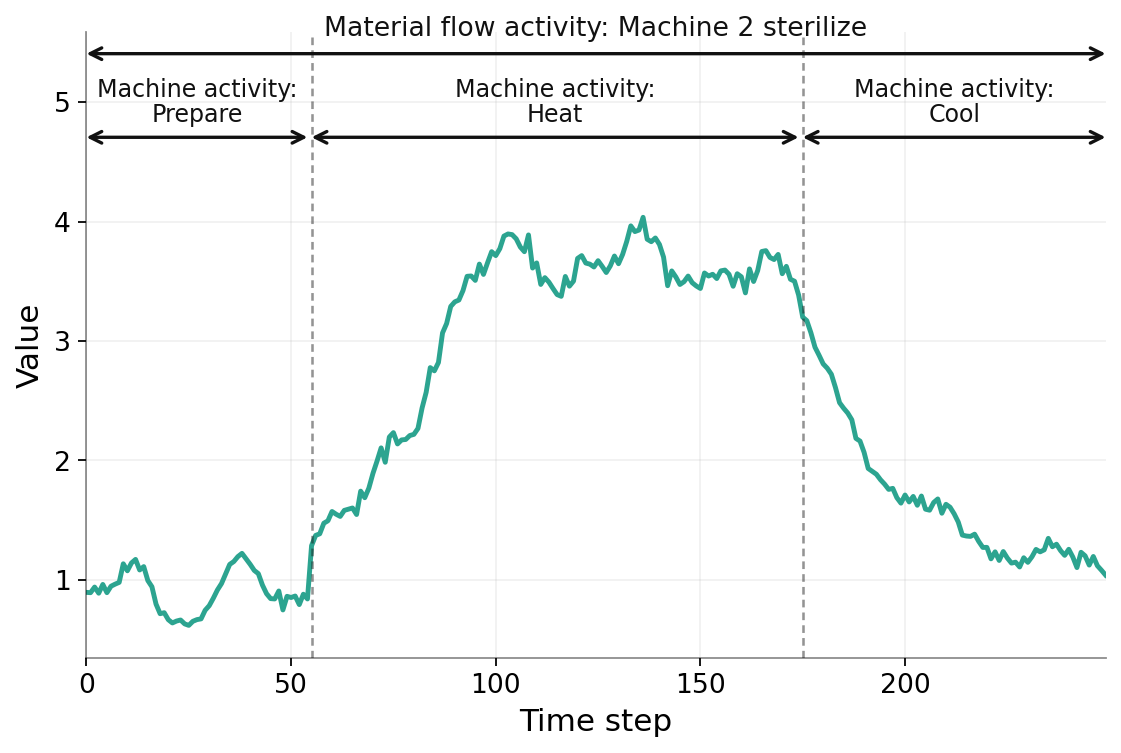

Saved visual to: visuals/machine_value_curve.pdf


In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Reproducibility
# ============================================================
np.random.seed(12)

# ============================================================
# Output folder
# ============================================================
os.makedirs("visuals", exist_ok=True)

# ============================================================
# Plot style
# ============================================================
plt.style.use("default")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",

    # Bigger text everywhere
    "font.size": 13,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,

    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 160,
})


# ============================================================
# Create synthetic value curve for Machine 2 sterilize
# ============================================================
# Activity lengths
n_prepare = 55
n_heat = 120
n_cool = 75

# Time indices
x_prepare = np.arange(n_prepare)
x_heat = np.arange(n_prepare, n_prepare + n_heat)
x_cool = np.arange(n_prepare + n_heat, n_prepare + n_heat + n_cool)

# Local normalized time per activity
t_prepare = np.linspace(0, 1, n_prepare)
t_heat = np.linspace(0, 1, n_heat)
t_cool = np.linspace(0, 1, n_cool)

# ------------------------------------------------------------
# Prepare: more dynamic preparation phase with peaks and valleys
# ------------------------------------------------------------
prepare_peak_1 = 0.28 * np.exp(-0.5 * ((t_prepare - 0.22) / 0.07) ** 2)
prepare_valley = -0.18 * np.exp(-0.5 * ((t_prepare - 0.48) / 0.08) ** 2)
prepare_peak_2 = 0.34 * np.exp(-0.5 * ((t_prepare - 0.72) / 0.09) ** 2)

value_prepare = (
    0.82
    + 0.08 * np.sin(4 * np.pi * t_prepare + 0.3)
    + 0.05 * np.sin(9 * np.pi * t_prepare + 0.8)
    + prepare_peak_1
    + prepare_valley
    + prepare_peak_2
    + 0.030 * np.random.randn(n_prepare)
)

# ------------------------------------------------------------
# Heat: strong ramp-up, high load, local peaks
# ------------------------------------------------------------
ramp_up = 1 / (1 + np.exp(-16 * (t_heat - 0.18)))
main_heat_load = 1.10 + 2.35 * ramp_up

heat_oscillation = (
    0.18 * np.sin(7 * np.pi * t_heat)
    + 0.10 * np.sin(15 * np.pi * t_heat + 0.7)
)

heat_peaks = (
    0.35 * np.exp(-0.5 * ((t_heat - 0.42) / 0.08) ** 2)
    + 0.28 * np.exp(-0.5 * ((t_heat - 0.72) / 0.10) ** 2)
)

value_heat = (
    main_heat_load
    + heat_oscillation
    + heat_peaks
    + 0.055 * np.random.randn(n_heat)
)

# ------------------------------------------------------------
# Cool: decreasing consumption after heating with small fluctuations
# ------------------------------------------------------------
cool_decay = 2.15 * np.exp(-3.4 * t_cool)

value_cool = (
    1.05
    + cool_decay
    + 0.09 * np.sin(5 * np.pi * t_cool + 0.5)
    + 0.04 * np.random.randn(n_cool)
)

# Concatenate full curve
x = np.concatenate([x_prepare, x_heat, x_cool])
value = np.concatenate([value_prepare, value_heat, value_cool])

# Avoid negative artifacts
value = np.clip(value, 0.05, None)


# ============================================================
# Segment boundaries and labels
# ============================================================
start_prepare = 0
end_prepare = n_prepare - 1

start_heat = n_prepare
end_heat = n_prepare + n_heat - 1

start_cool = n_prepare + n_heat
end_cool = n_prepare + n_heat + n_cool - 1

segments = [
    ("Prepare", start_prepare, end_prepare),
    ("Heat", start_heat, end_heat),
    ("Cool", start_cool, end_cool),
]


# ============================================================
# Plot
# ============================================================
fig, ax = plt.subplots(figsize=(7.2, 4.9))

# Same bluish-green color as previous visual
curve_color = "#1f9e89"
line_color = "#111111"

curve_lw = 2.2
bar_lw = 1.5

# Main value curve
ax.plot(
    x,
    value,
    color=curve_color,
    linewidth=curve_lw,
    alpha=0.94,
)

# Axis labels
ax.set_xlabel("Time step", fontsize=14)
ax.set_ylabel("Value", fontsize=14)

# Limits with space for top labels and bars
y_min = 0.35
y_max = max(value) + 1.55
ax.set_ylim(y_min, y_max)
ax.set_xlim(0, len(x) - 1)

# Top positions for labels and interval bars
material_bar_y = y_max - 0.18
material_text_y = material_bar_y + 0.10

# Lower machine-activity row to give more space
activity_bar_y = y_max - 0.88
activity_text_y = activity_bar_y + 0.09

# ------------------------------------------------------------
# Whole material-flow interval
# ------------------------------------------------------------
ax.annotate(
    "",
    xy=(0, material_bar_y),
    xytext=(len(x) - 1, material_bar_y),
    arrowprops=dict(
        arrowstyle="<->",
        color=line_color,
        linewidth=bar_lw,
        shrinkA=0,
        shrinkB=0,
    ),
)

ax.text(
    (len(x) - 1) / 2,
    material_text_y,
    "Material flow activity: Machine 2 sterilize",
    ha="center",
    va="bottom",
    fontsize=12.0,
    color=line_color,
)

# ------------------------------------------------------------
# Machine activity intervals
# ------------------------------------------------------------
for name, start, end in segments:
    mid = (start + end) / 2

    ax.annotate(
        "",
        xy=(start, activity_bar_y),
        xytext=(end, activity_bar_y),
        arrowprops=dict(
            arrowstyle="<->",
            color=line_color,
            linewidth=bar_lw,
            shrinkA=0,
            shrinkB=0,
        ),
    )

    ax.text(
        mid,
        activity_text_y,
        f"Machine activity:\n{name}",
        ha="center",
        va="bottom",
        fontsize=10.7,
        linespacing=1.05,
        color=line_color,
    )

# Vertical separators between machine activities
for boundary in [start_heat, start_cool]:
    ax.axvline(
        boundary,
        color=line_color,
        linestyle=(0, (3, 2)),
        linewidth=1.15,
        alpha=0.45,
    )

# Grid and cosmetic improvements
ax.grid(True, alpha=0.18)
ax.set_facecolor("white")
ax.spines["left"].set_alpha(0.45)
ax.spines["bottom"].set_alpha(0.45)
fig.patch.set_facecolor("white")

plt.tight_layout()

# ============================================================
# Save high-resolution PDF
# ============================================================
pdf_path = os.path.join("visuals", "machine_value_curve.pdf")

plt.savefig(
    pdf_path,
    format="pdf",
    bbox_inches="tight",
    dpi=600,
    facecolor="white",
)

plt.show()

print(f"Saved visual to: {pdf_path}")